# 🩺 Diabetes Prediction — ML Pipeline + Model Export
**Dataset:** PIMA Indians Diabetes (768 rows × 8 features)  
**Goal:** Train the best classifier, evaluate rigorously, then save artifacts for a Streamlit app.

> **Saved files (used by Streamlit):**  
> `diabetes_model.pkl` — trained VotingClassifier  
> `diabetes_scaler.pkl` — RobustScaler fitted on training data  
> `diabetes_imputer.pkl` — KNNImputer fitted on raw features

---
**Table of Contents:**  
1. Imports · 2. Data Loading & EDA · 3. Preprocessing · 4. Feature Engineering  
5. Model Training & CV · 6. Hyperparameter Tuning · 7. Evaluation · 8. Save Artifacts

---
## 1. Imports

In [16]:
import numpy as np
import pandas as pd
import joblib
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import RobustScaler
from sklearn.impute import KNNImputer
from sklearn.model_selection import (
    train_test_split, StratifiedKFold,
    cross_val_score, RandomizedSearchCV
)
from sklearn.base import clone
from sklearn.neighbors import NearestNeighbors
from sklearn.feature_selection import SelectKBest, f_classif

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    ExtraTreesClassifier, AdaBoostClassifier, VotingClassifier
)

try:
    from xgboost import XGBClassifier
    XGBOOST = True
except ImportError:
    XGBOOST = False

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, precision_recall_curve
)

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)
C_GREEN, C_RED, C_BLUE, C_ORANGE = '#4CAF50', '#F44336', '#2196F3', '#FF9800'

print(f"✅ All imports loaded  |  XGBoost: {XGBOOST}")

✅ All imports loaded  |  XGBoost: True


---
## 2. Data Loading & EDA

In [17]:
df = pd.read_csv('../datasets/diabetes.csv')

print("=" * 55)
print(f"  Rows × Columns  : {df.shape}")
print(f"  Target balance  : {df['Outcome'].value_counts().to_dict()}")
print(f"  Class ratio     : {df['Outcome'].value_counts(normalize=True).round(3).to_dict()}")
print("=" * 55)
df.head()

  Rows × Columns  : (768, 9)
  Target balance  : {0: 500, 1: 268}
  Class ratio     : {0: 0.651, 1: 0.349}


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [18]:
df.describe().T.style \
    .background_gradient(cmap='Blues', subset=['mean','std']) \
    .format(precision=2)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,768.00,3.85,3.37,0.00,1.00,3.00,6.00,17.00
Glucose,768.00,120.89,31.97,0.00,99.00,117.00,140.25,199.00
BloodPressure,768.00,69.11,19.36,0.00,62.00,72.00,80.00,122.00
SkinThickness,768.00,20.54,15.95,0.00,0.00,23.00,32.00,99.00
Insulin,768.00,79.80,115.24,0.00,0.00,30.50,127.25,846.00
BMI,768.00,31.99,7.88,0.00,27.30,32.00,36.60,67.10
DiabetesPedigreeFunction,768.00,0.47,0.33,0.08,0.24,0.37,0.63,2.42
Age,768.00,33.24,11.76,21.00,24.00,29.00,41.00,81.00
Outcome,768.00,0.35,0.48,0.00,0.00,0.00,1.00,1.00


In [19]:
ZERO_INVALID = ['Glucose','BloodPressure','SkinThickness','Insulin','BMI']

pd.DataFrame({
    'Dtype'        : df.dtypes,
    'Null Count'   : df.isnull().sum(),
    'Zero Count'   : (df == 0).sum(),
    'Invalid Zeros': [('⚠ YES – fix required' if c in ZERO_INVALID else '✅ OK') for c in df.columns],
    'Unique'       : df.nunique()
}).style.background_gradient(cmap='OrRd', subset=['Zero Count'])

,Dtype,Null Count,Zero Count,Invalid Zeros,Unique
Pregnancies,int64,0,111,✅ OK,17
Glucose,int64,0,5,⚠ YES – fix required,136
BloodPressure,int64,0,35,⚠ YES – fix required,47
SkinThickness,int64,0,227,⚠ YES – fix required,51
Insulin,int64,0,374,⚠ YES – fix required,186
BMI,float64,0,11,⚠ YES – fix required,248
DiabetesPedigreeFunction,float64,0,0,✅ OK,517
Age,int64,0,0,✅ OK,52
Outcome,int64,0,500,✅ OK,2


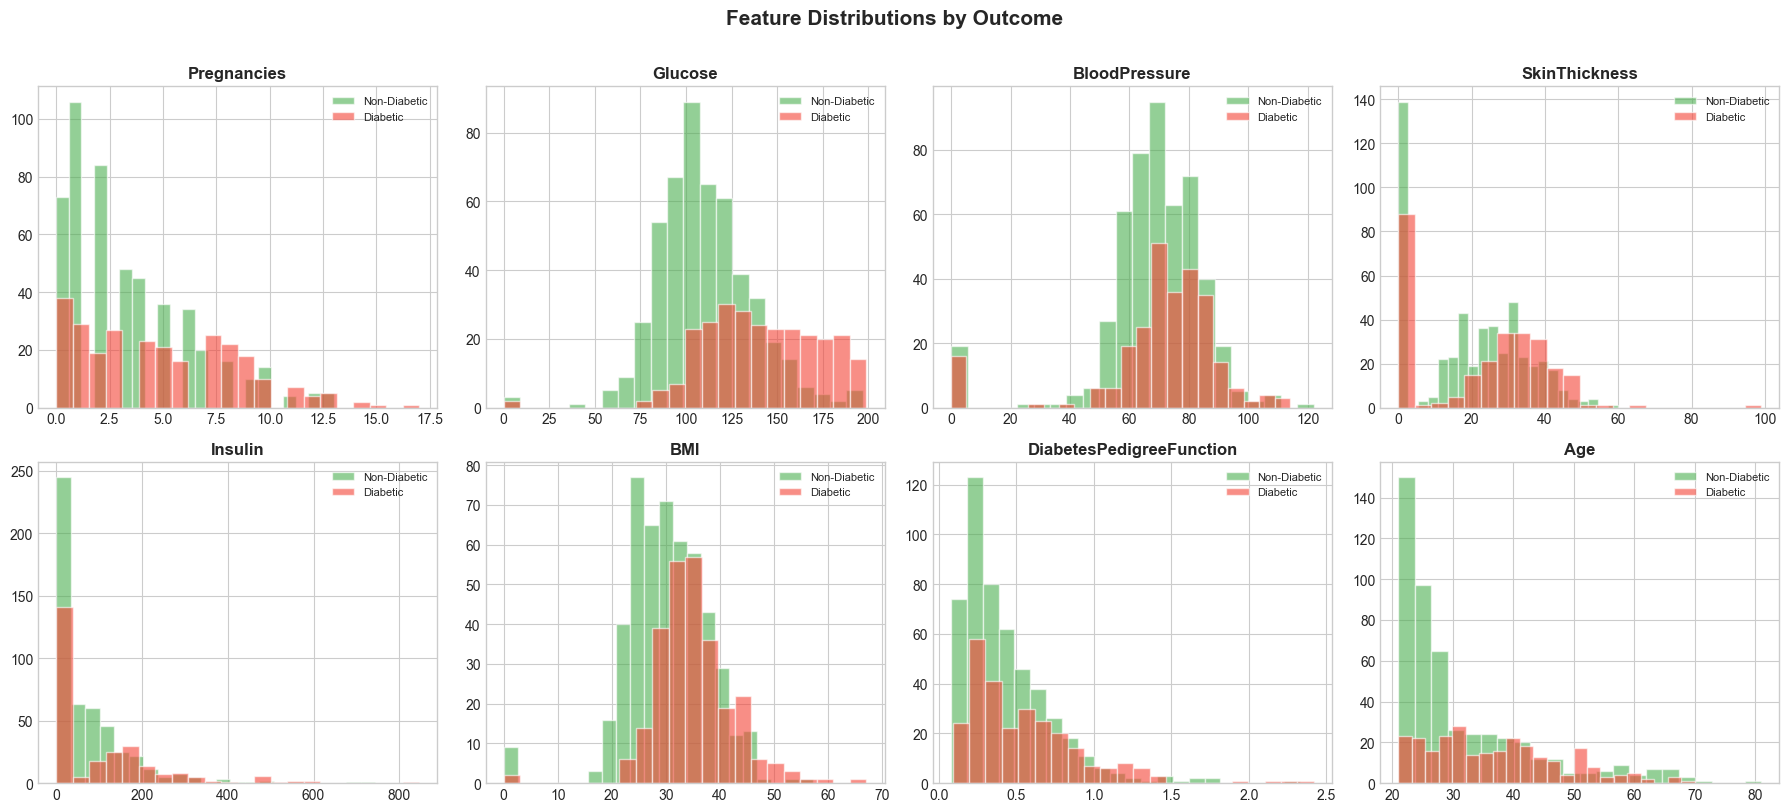

In [20]:
features = [c for c in df.columns if c != 'Outcome']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, feat in enumerate(features):
    for outcome, color, lbl in zip([0,1],[C_GREEN,C_RED],['Non-Diabetic','Diabetic']):
        axes[i].hist(df[df['Outcome']==outcome][feat], bins=22,
                     alpha=0.6, color=color, label=lbl, edgecolor='white')
    axes[i].set_title(feat, fontweight='bold'); axes[i].legend(fontsize=8)
plt.suptitle('Feature Distributions by Outcome', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

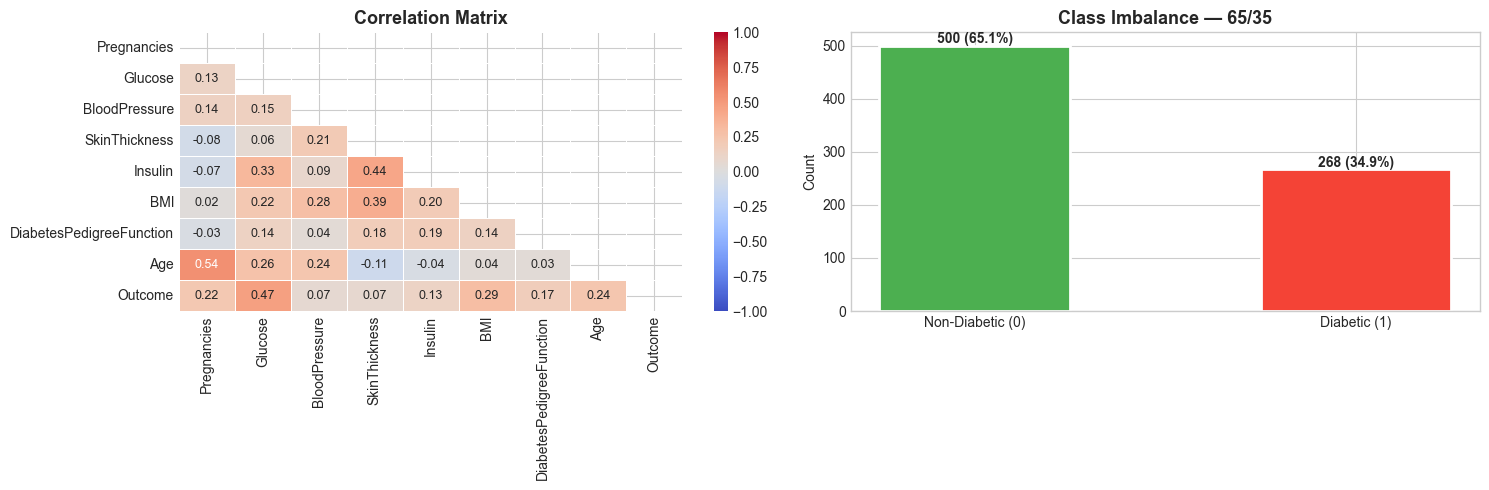

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, ax=axes[0], vmin=-1, vmax=1, annot_kws={'size':9})
axes[0].set_title('Correlation Matrix', fontweight='bold', fontsize=13)

counts = df['Outcome'].value_counts()
bars = axes[1].bar(['Non-Diabetic (0)','Diabetic (1)'], counts,
                    color=[C_GREEN,C_RED], edgecolor='white', linewidth=2, width=0.5)
for bar, count in zip(bars, counts):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+4,
                 f'{count} ({count/len(df)*100:.1f}%)', ha='center', fontweight='bold')
axes[1].set_title('Class Imbalance — 65/35', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Count')
plt.tight_layout(); plt.show()

---
## 3. Preprocessing

| Step | Technique | Reason |
|------|-----------|--------|
| Zero → NaN | Domain knowledge | Glucose/BMI/BP of 0 is biologically impossible |
| Missing fill | KNNImputer (k=5) | Uses neighbouring rows — far better than mean fill |
| Outlier capping | IQR × 1.5 | Clips extremes without deleting any rows |
| Class balancing | Manual SMOTE (train only) | Fixes 65/35 imbalance with zero data leakage |
| Scaling | RobustScaler | Median + IQR — not skewed by remaining outliers |

In [22]:
# Step 1 — Replace biologically impossible zeros with NaN
df_clean = df.copy()
for col in ZERO_INVALID:
    n = (df_clean[col] == 0).sum()
    df_clean[col] = df_clean[col].replace(0, np.nan)
    print(f"  {col:<22}: {n} zeros → NaN")
print(f"\nTotal missing values: {df_clean.isnull().sum().sum()}")

  Glucose               : 5 zeros → NaN
  BloodPressure         : 35 zeros → NaN
  SkinThickness         : 227 zeros → NaN
  Insulin               : 374 zeros → NaN
  BMI                   : 11 zeros → NaN

Total missing values: 652


In [23]:
# Step 2 — KNN Imputation (fit on features only, NEVER the target)
X_raw = df_clean.drop('Outcome', axis=1)
y     = df_clean['Outcome']

knn_imputer = KNNImputer(n_neighbors=5, weights='distance')
X_imputed   = pd.DataFrame(knn_imputer.fit_transform(X_raw), columns=X_raw.columns)
print(f"✅ KNN Imputation done | remaining NaN: {X_imputed.isnull().sum().sum()}")

✅ KNN Imputation done | remaining NaN: 0


In [24]:
# Step 3 — IQR outlier capping
def cap_outliers(df, factor=1.5):
    df2 = df.copy()
    for col in df.columns:
        Q1, Q3 = df[col].quantile([0.25, 0.75]); IQR = Q3 - Q1
        n_out = ((df[col] < Q1-factor*IQR) | (df[col] > Q3+factor*IQR)).sum()
        df2[col] = df2[col].clip(Q1 - factor*IQR, Q3 + factor*IQR)
        if n_out > 0: print(f"  {col:<28}: {n_out} outliers capped")
    return df2

X_capped = cap_outliers(X_imputed)
print("✅ Outlier capping complete")

  Pregnancies                 : 4 outliers capped
  BloodPressure               : 14 outliers capped
  SkinThickness               : 6 outliers capped
  Insulin                     : 33 outliers capped
  BMI                         : 8 outliers capped
  DiabetesPedigreeFunction    : 29 outliers capped
  Age                         : 9 outliers capped
✅ Outlier capping complete


In [25]:
# Step 4 — Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X_capped, y, test_size=0.20, random_state=42, stratify=y)
print(f"Train : {X_train.shape}  |  Test : {X_test.shape}")
print(f"Train balance : {dict(y_train.value_counts())}")
print(f"Test  balance : {dict(y_test.value_counts())}")

Train : (614, 8)  |  Test : (154, 8)
Train balance : {0: 400, 1: 214}
Test  balance : {0: 100, 1: 54}


In [26]:
# Step 5 — Manual SMOTE on training data ONLY
def manual_smote(X, y, k=5, seed=42):
    """Oversample minority class via KNN interpolation."""
    rng = np.random.default_rng(seed)
    X, y = np.array(X, dtype=float), np.array(y)
    classes, counts = np.unique(y, return_counts=True)
    minority = classes[np.argmin(counts)]
    n_gen    = counts.max() - counts.min()
    X_min    = X[y == minority]
    nn       = NearestNeighbors(n_neighbors=k+1).fit(X_min)
    _, idxs  = nn.kneighbors(X_min)
    synthetic = [
        X_min[i%len(X_min)] +
        rng.random() * (X_min[idxs[i%len(X_min), rng.integers(1,k+1)]] - X_min[i%len(X_min)])
        for i in range(n_gen)
    ]
    X_res = np.vstack([X, np.vstack(synthetic)])
    y_res = np.concatenate([y, np.full(n_gen, minority)])
    perm  = rng.permutation(len(y_res))
    return X_res[perm], y_res[perm]

X_train_sm, y_train_sm = manual_smote(X_train.values, y_train.values)
print(f"Before SMOTE : {dict(zip(*np.unique(y_train, return_counts=True)))}")
print(f"After  SMOTE : {dict(zip(*np.unique(y_train_sm, return_counts=True)))}")

Before SMOTE : {0: 400, 1: 214}
After  SMOTE : {0: 400, 1: 400}


In [27]:
# Step 6 — RobustScaler (fit on train only)
scaler     = RobustScaler()
X_train_sc = scaler.fit_transform(X_train_sm)
X_test_sc  = scaler.transform(X_test)
print(f"✅ Scaling done | Train: {X_train_sc.shape} | Test: {X_test_sc.shape}")

✅ Scaling done | Train: (800, 8) | Test: (154, 8)


---
## 4. Feature Engineering

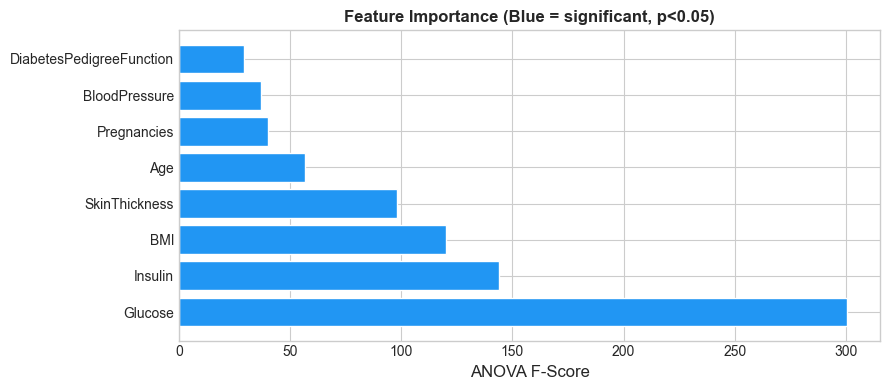

                 Feature    F-Score      p-value
                 Glucose 300.364403 2.356359e-57
                 Insulin 144.146868 1.205960e-30
                     BMI 119.990175 4.129417e-26
           SkinThickness  98.099377 6.852955e-22
                     Age  56.494922 1.514832e-13
             Pregnancies  39.912141 4.411227e-10
           BloodPressure  37.085950 1.755869e-09
DiabetesPedigreeFunction  29.223789 8.522795e-08


In [28]:
# ANOVA F-test on base features
sel = SelectKBest(f_classif, k='all').fit(X_train_sc, y_train_sm)
fimp = pd.DataFrame({'Feature': X_capped.columns,
                     'F-Score': sel.scores_,
                     'p-value': sel.pvalues_}).sort_values('F-Score', ascending=False)

fig, ax = plt.subplots(figsize=(9, 4))
clrs = [C_BLUE if p < 0.05 else '#BDBDBD' for p in fimp['p-value']]
ax.barh(fimp['Feature'], fimp['F-Score'], color=clrs, edgecolor='white')
ax.set_xlabel('ANOVA F-Score', fontsize=12)
ax.set_title('Feature Importance (Blue = significant, p<0.05)', fontweight='bold')
plt.tight_layout(); plt.show()
print(fimp.to_string(index=False))

In [29]:
def add_features(df):
    """Deterministic interaction features - safe to apply before split."""
    df = df.copy()
    df['Glucose_BMI']     = df['Glucose'] * df['BMI']
    df['Age_BMI']         = df['Age'] * df['BMI']
    df['Insulin_Glucose'] = df['Insulin'] / (df['Glucose'] + 1e-6)
    df['Preg_Age']        = df['Pregnancies'] / (df['Age'] + 1e-6)
    df['Glucose2']        = df['Glucose'] ** 2
    df['BMI2']            = df['BMI'] ** 2
    df['Age_Glucose']     = df['Age'] * df['Glucose']
    df['DPF_Glucose']     = df['DiabetesPedigreeFunction'] * df['Glucose']
    return df

# Rebuild pipeline with engineered features
X_fe = cap_outliers(add_features(X_capped))
print(f"Feature count: {X_capped.shape[1]} -> {X_fe.shape[1]}")

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y, test_size=0.20, random_state=42, stratify=y)
X_tr_sm, y_tr_sm = manual_smote(X_train_fe.values, y_train_fe.values)

scaler_fe  = RobustScaler()
X_tr_sc    = scaler_fe.fit_transform(X_tr_sm)
X_te_sc    = scaler_fe.transform(X_test_fe)
print(f"✅ Pipeline rebuilt | Train: {X_tr_sc.shape} | Test: {X_te_sc.shape}")

  Glucose_BMI                 : 16 outliers capped
  Age_BMI                     : 9 outliers capped
  Insulin_Glucose             : 14 outliers capped
  Preg_Age                    : 2 outliers capped
  Glucose2                    : 29 outliers capped
  BMI2                        : 16 outliers capped
  Age_Glucose                 : 25 outliers capped
  DPF_Glucose                 : 30 outliers capped
Feature count: 8 -> 16
✅ Pipeline rebuilt | Train: (800, 16) | Test: (154, 16)


---
## 5. Model Training — 10 Classifiers (10-fold Stratified CV)

In [30]:
models = {
    'Logistic Regression'   : LogisticRegression(max_iter=2000, C=1.2, random_state=42),
    'K-Nearest Neighbors'   : KNeighborsClassifier(n_neighbors=11, weights='distance'),
    'Naive Bayes'           : GaussianNB(),
    'Linear Discriminant'   : LinearDiscriminantAnalysis(),
    'Decision Tree'         : DecisionTreeClassifier(max_depth=6, min_samples_leaf=4, random_state=42),
    'Support Vector Machine': SVC(kernel='rbf', C=8, gamma='scale', probability=True, random_state=42),
    'AdaBoost'              : AdaBoostClassifier(n_estimators=250, learning_rate=0.05, random_state=42),
    'Random Forest'         : RandomForestClassifier(n_estimators=700, min_samples_leaf=2,
                                 class_weight='balanced_subsample', random_state=42, n_jobs=-1),
    'Extra Trees'           : ExtraTreesClassifier(n_estimators=800, min_samples_leaf=2,
                                 class_weight='balanced', random_state=42, n_jobs=-1),
    'Gradient Boosting'     : GradientBoostingClassifier(n_estimators=300, learning_rate=0.03,
                                 max_depth=3, subsample=0.9, random_state=42),
}
if XGBOOST:
    models['XGBoost'] = XGBClassifier(n_estimators=500, learning_rate=0.05, max_depth=4,
        min_child_weight=2, subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.5, eval_metric='logloss', random_state=42)

print(f"✅ {len(models)} models configured")

✅ 11 models configured


In [31]:
cv_strat = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
results  = {}

print(f"{'Model':<28} {'CV Acc':>9} {'±Std':>7} {'Test Acc':>10} {'F1':>7} {'AUC':>8}")
print('─' * 73)

for name, model in models.items():
    cv_s = cross_val_score(model, X_tr_sc, y_tr_sm, cv=cv_strat, scoring='accuracy', n_jobs=-1)
    model.fit(X_tr_sc, y_tr_sm)
    yp   = model.predict(X_te_sc)
    ypr  = model.predict_proba(X_te_sc)[:,1] if hasattr(model,'predict_proba') else None
    ta   = accuracy_score(y_test_fe, yp)
    f1   = f1_score(y_test_fe, yp)
    auc  = roc_auc_score(y_test_fe, ypr) if ypr is not None else 0.0
    results[name] = dict(model=model, cv_mean=cv_s.mean(), cv_std=cv_s.std(),
                         test_acc=ta, f1=f1, auc=auc, y_pred=yp, y_proba=ypr)
    print(f"{name:<28} {cv_s.mean():>9.4f} {cv_s.std():>7.4f} {ta:>10.4f} {f1:>7.4f} {auc:>8.4f}")

print('─' * 73)
print(f"Best by CV  : {max(results, key=lambda k: results[k]['cv_mean'])}")
print(f"Best by Test: {max(results, key=lambda k: results[k]['test_acc'])}")

Model                           CV Acc    ±Std   Test Acc      F1      AUC
─────────────────────────────────────────────────────────────────────────
Logistic Regression             0.7650  0.0414     0.7468  0.6723   0.8193
K-Nearest Neighbors             0.8087  0.0321     0.7013  0.6290   0.7767
Naive Bayes                     0.7488  0.0511     0.7273  0.6441   0.8061
Linear Discriminant             0.7700  0.0430     0.7468  0.6777   0.8246
Decision Tree                   0.7575  0.0281     0.7338  0.6667   0.7882
Support Vector Machine          0.8037  0.0440     0.7338  0.6496   0.7804
AdaBoost                        0.7687  0.0302     0.7273  0.6613   0.8194
Random Forest                   0.8237  0.0442     0.7403  0.6667   0.8215
Extra Trees                     0.8337  0.0430     0.7338  0.6555   0.8191
Gradient Boosting               0.8113  0.0351     0.7143  0.6271   0.8141
XGBoost                         0.8075  0.0478     0.7338  0.6496   0.8139
──────────────────────────

---
## 6. Hyperparameter Tuning (RandomizedSearchCV, 50 iter, 5-fold)

In [32]:
param_grids = {
    'Random Forest': {
        'n_estimators': [300,500,700,900], 'max_depth': [None,8,12,16],
        'min_samples_split': [2,5,10], 'min_samples_leaf': [1,2,4],
        'max_features': ['sqrt','log2'], 'class_weight': ['balanced','balanced_subsample'],
    },
    'Extra Trees': {
        'n_estimators': [300,500,700,900], 'max_depth': [None,8,12],
        'min_samples_split': [2,5], 'min_samples_leaf': [1,2],
        'max_features': ['sqrt','log2'], 'class_weight': ['balanced','balanced_subsample'],
    },
    'Gradient Boosting': {
        'n_estimators': [150,250,350,500], 'learning_rate': [0.01,0.02,0.05,0.1],
        'max_depth': [2,3,4], 'subsample': [0.7,0.85,1.0],
    },
    'Support Vector Machine': {
        'C': [0.5,1,5,10,20,50], 'gamma': ['scale','auto',0.1,0.01,0.001],
        'kernel': ['rbf'], 'probability': [True],
    },
}
if XGBOOST:
    param_grids['XGBoost'] = {
        'n_estimators': [300,500,700], 'max_depth': [3,4,5],
        'learning_rate': [0.01,0.05,0.1], 'subsample': [0.7,0.85,1.0],
        'colsample_bytree': [0.7,0.85,1.0], 'reg_alpha': [0.0,0.1,0.5], 'reg_lambda': [1.0,1.5,2.0],
    }

results_df = pd.DataFrame([
    {'Model': k, 'CV Mean': v['cv_mean'], 'Test Acc': v['test_acc'], 'F1': v['f1'], 'AUC': v['auc']}
    for k, v in results.items()
]).sort_values('CV Mean', ascending=False).reset_index(drop=True)

to_tune = [m for m in results_df['Model'].tolist() if m in param_grids][:5]
print(f"Tuning: {to_tune}")

Tuning: ['Extra Trees', 'Random Forest', 'Gradient Boosting', 'XGBoost', 'Support Vector Machine']


In [33]:
tuned   = {}
tune_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name in to_tune:
    print(f"\n🔧 {name} ...")
    estimator = clone(results[name]['model'])
    if isinstance(estimator, SVC): estimator.set_params(probability=True)

    search = RandomizedSearchCV(estimator, param_grids[name], n_iter=50,
                                cv=tune_cv, scoring='accuracy', n_jobs=-1,
                                random_state=42, verbose=0)
    search.fit(X_tr_sc, y_tr_sm)
    bm = search.best_estimator_
    yp = bm.predict(X_te_sc)
    ypr = bm.predict_proba(X_te_sc)[:,1]
    tuned[name] = dict(model=bm, best_params=search.best_params_,
                       cv_score=search.best_score_,
                       test_acc=accuracy_score(y_test_fe, yp),
                       f1=f1_score(y_test_fe, yp),
                       auc=roc_auc_score(y_test_fe, ypr),
                       y_pred=yp, y_proba=ypr)
    print(f"   CV={search.best_score_:.4f}  Test={tuned[name]['test_acc']:.4f}  AUC={tuned[name]['auc']:.4f}")
    print(f"   {search.best_params_}")


🔧 Extra Trees ...
   CV=0.8300  Test=0.7143  AUC=0.8118
   {'n_estimators': 700, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': None, 'class_weight': 'balanced'}

🔧 Random Forest ...
   CV=0.8250  Test=0.7078  AUC=0.8128
   {'n_estimators': 700, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 12, 'class_weight': 'balanced_subsample'}

🔧 Gradient Boosting ...
   CV=0.8138  Test=0.7078  AUC=0.8163
   {'subsample': 0.7, 'n_estimators': 150, 'max_depth': 4, 'learning_rate': 0.02}

🔧 XGBoost ...
   CV=0.8063  Test=0.7338  AUC=0.7937
   {'subsample': 0.7, 'reg_lambda': 1.5, 'reg_alpha': 0.1, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.1, 'colsample_bytree': 1.0}

🔧 Support Vector Machine ...
   CV=0.7975  Test=0.7208  AUC=0.7987
   {'probability': True, 'kernel': 'rbf', 'gamma': 'scale', 'C': 1}


In [34]:
# Soft Voting Ensemble of all tuned models
print("\n🤝 Building Soft Voting Ensemble ...")
voting_clf = VotingClassifier(
    estimators=[(n, v['model']) for n, v in tuned.items()],
    voting='soft', n_jobs=-1
)
voting_clf.fit(X_tr_sc, y_tr_sm)
yv   = voting_clf.predict(X_te_sc)
yprv = voting_clf.predict_proba(X_te_sc)[:,1]

tuned['Voting Ensemble'] = dict(
    model=voting_clf, cv_score=0,
    test_acc=accuracy_score(y_test_fe, yv),
    f1=f1_score(y_test_fe, yv),
    auc=roc_auc_score(y_test_fe, yprv),
    y_pred=yv, y_proba=yprv
)
print(f"   Test Accuracy : {tuned['Voting Ensemble']['test_acc']:.4f}")
print(f"   AUC-ROC       : {tuned['Voting Ensemble']['auc']:.4f}")


🤝 Building Soft Voting Ensemble ...
   Test Accuracy : 0.7208
   AUC-ROC       : 0.8143


---
## 7. Evaluation & Comparison

In [35]:
rows = (
    [{'Model': k,       'Type':'Baseline','CV Acc':v['cv_mean'],
      'Test Acc':v['test_acc'],'F1':v['f1'],'AUC':v['auc']} for k,v in results.items()]
  + [{'Model': k+' ★', 'Type':'Tuned',  'CV Acc':v.get('cv_score',0),
      'Test Acc':v['test_acc'],'F1':v['f1'],'AUC':v['auc']} for k,v in tuned.items()]
)
cmp = pd.DataFrame(rows).sort_values('Test Acc', ascending=False).reset_index(drop=True)
cmp.style \
    .background_gradient(subset=['Test Acc','F1','AUC'], cmap='RdYlGn') \
    .format({'CV Acc':'{:.4f}','Test Acc':'{:.4f}','F1':'{:.4f}','AUC':'{:.4f}'}) \
    .set_properties(**{'font-size':'11px'})

,Model,Type,CV Acc,Test Acc,F1,AUC
0,Logistic Regression,Baseline,0.7650,0.7468,0.6723,0.8193
1,Linear Discriminant,Baseline,0.7700,0.7468,0.6777,0.8246
2,Random Forest,Baseline,0.8237,0.7403,0.6667,0.8215
3,XGBoost ★,Tuned,0.8063,0.7338,0.6435,0.7937
4,XGBoost,Baseline,0.8075,0.7338,0.6496,0.8139
5,Extra Trees,Baseline,0.8337,0.7338,0.6555,0.8191
6,Support Vector Machine,Baseline,0.8037,0.7338,0.6496,0.7804
7,Decision Tree,Baseline,0.7575,0.7338,0.6667,0.7882
8,AdaBoost,Baseline,0.7687,0.7273,0.6613,0.8194
9,Naive Bayes,Baseline,0.7488,0.7273,0.6441,0.8061


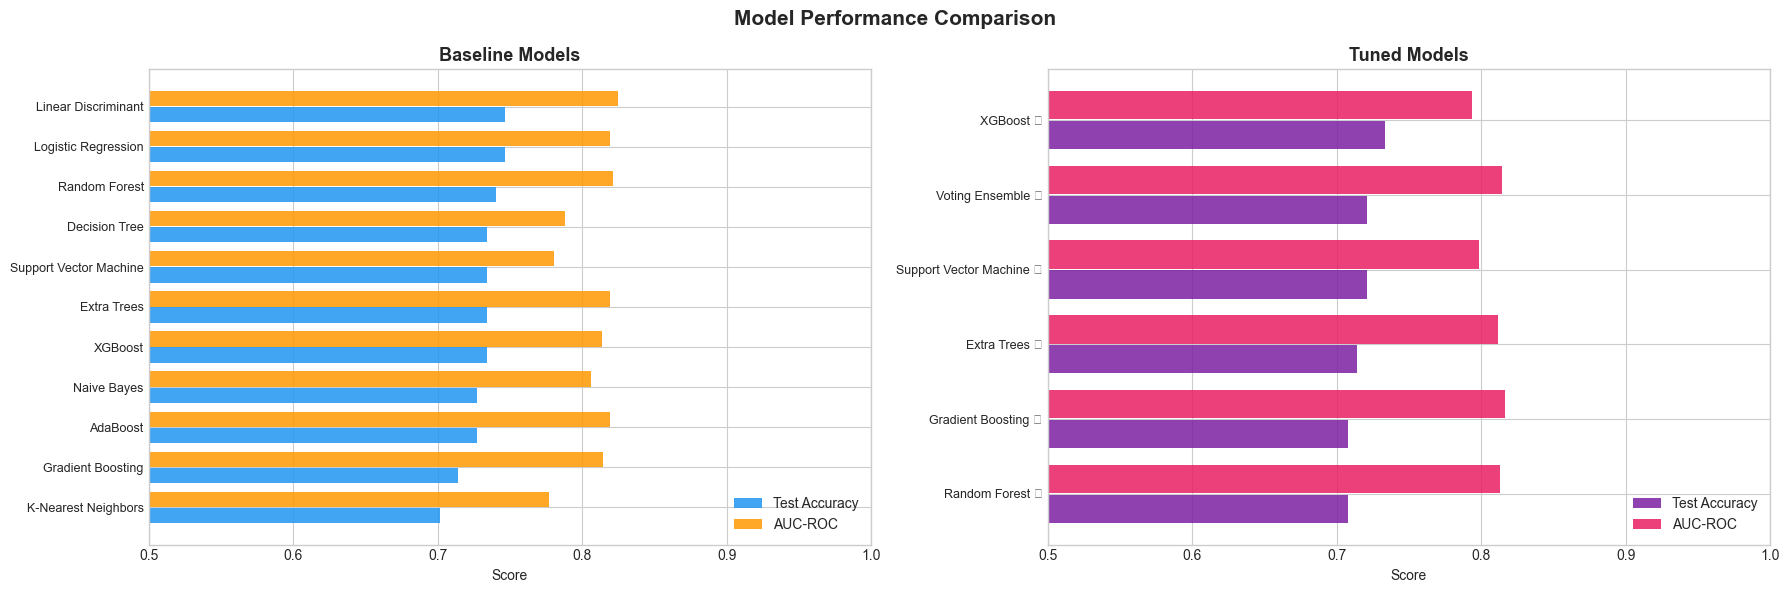

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
for ax, mask, title, c1, c2 in [
    (axes[0],'Baseline','Baseline Models', C_BLUE, C_ORANGE),
    (axes[1],'Tuned',   'Tuned Models',   '#7B1FA2','#E91E63'),
]:
    data = cmp[cmp['Type']==mask].sort_values('Test Acc', ascending=True)
    x = np.arange(len(data))
    ax.barh(x-0.2, data['Test Acc'], 0.38, label='Test Accuracy', color=c1, alpha=0.85)
    ax.barh(x+0.2, data['AUC'],      0.38, label='AUC-ROC',       color=c2, alpha=0.85)
    ax.set_yticks(x); ax.set_yticklabels(data['Model'], fontsize=9)
    ax.set_xlim(0.5, 1.0); ax.set_xlabel('Score')
    ax.set_title(title, fontweight='bold', fontsize=13); ax.legend(loc='lower right')
plt.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()

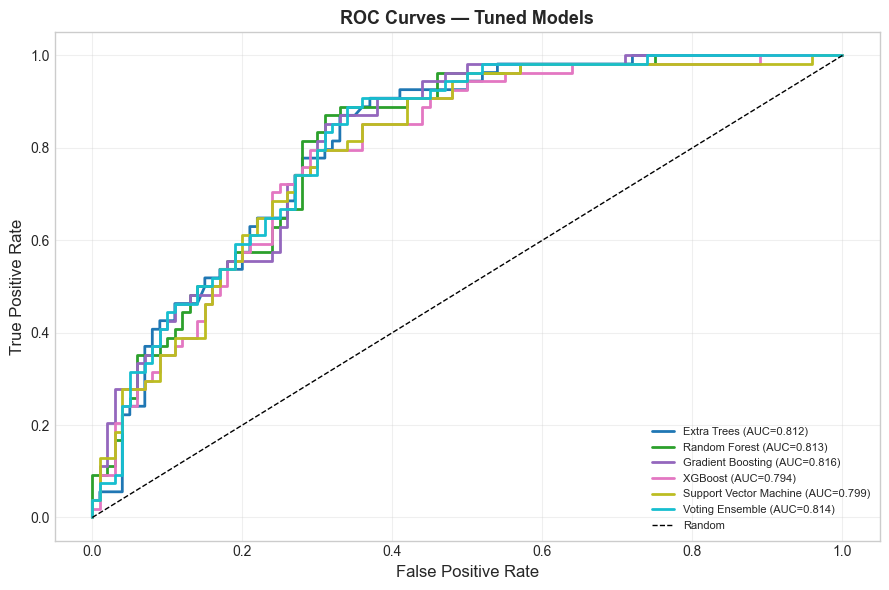

In [37]:
fig, ax = plt.subplots(figsize=(9, 6))
palette = plt.cm.tab10(np.linspace(0, 1, len(tuned)))
for (name, v), color in zip(tuned.items(), palette):
    fpr, tpr, _ = roc_curve(y_test_fe, v['y_proba'])
    ax.plot(fpr, tpr, label=f"{name} (AUC={v['auc']:.3f})", linewidth=2, color=color)
ax.plot([0,1],[0,1],'k--',linewidth=1,label='Random')
ax.set_xlabel('False Positive Rate',fontsize=12); ax.set_ylabel('True Positive Rate',fontsize=12)
ax.set_title('ROC Curves — Tuned Models', fontsize=13, fontweight='bold')
ax.legend(loc='lower right', fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [38]:
best_name = max(tuned, key=lambda k: tuned[k]['test_acc'])
best      = tuned[best_name]

print("=" * 55)
print(f"  BEST MODEL    : {best_name}")
print(f"  Test Accuracy : {best['test_acc']:.4f}  ({best['test_acc']*100:.2f}%)")
print(f"  F1 Score      : {best['f1']:.4f}")
print(f"  AUC-ROC       : {best['auc']:.4f}")
print("=" * 55)
print()
print(classification_report(y_test_fe, best['y_pred'],
                             target_names=['Non-Diabetic','Diabetic']))

  BEST MODEL    : XGBoost
  Test Accuracy : 0.7338  (73.38%)
  F1 Score      : 0.6435
  AUC-ROC       : 0.7937

              precision    recall  f1-score   support

Non-Diabetic       0.82      0.76      0.79       100
    Diabetic       0.61      0.69      0.64        54

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.72       154
weighted avg       0.74      0.73      0.74       154



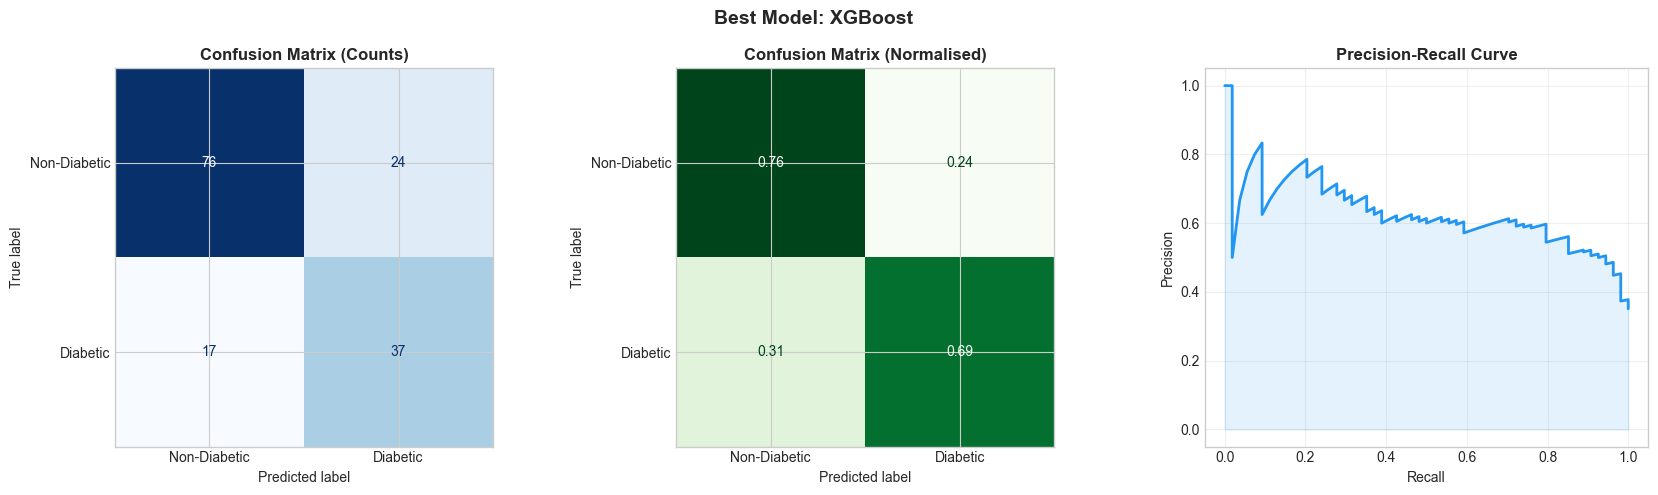

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

cm = confusion_matrix(y_test_fe, best['y_pred'])
ConfusionMatrixDisplay(cm, display_labels=['Non-Diabetic','Diabetic']).plot(
    ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix (Counts)', fontweight='bold')

cm_n = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_n, display_labels=['Non-Diabetic','Diabetic']).plot(
    ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title('Confusion Matrix (Normalised)', fontweight='bold')

prec, rec, _ = precision_recall_curve(y_test_fe, best['y_proba'])
axes[2].plot(rec, prec, color=C_BLUE, linewidth=2)
axes[2].fill_between(rec, prec, alpha=0.12, color=C_BLUE)
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.suptitle(f'Best Model: {best_name}', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()

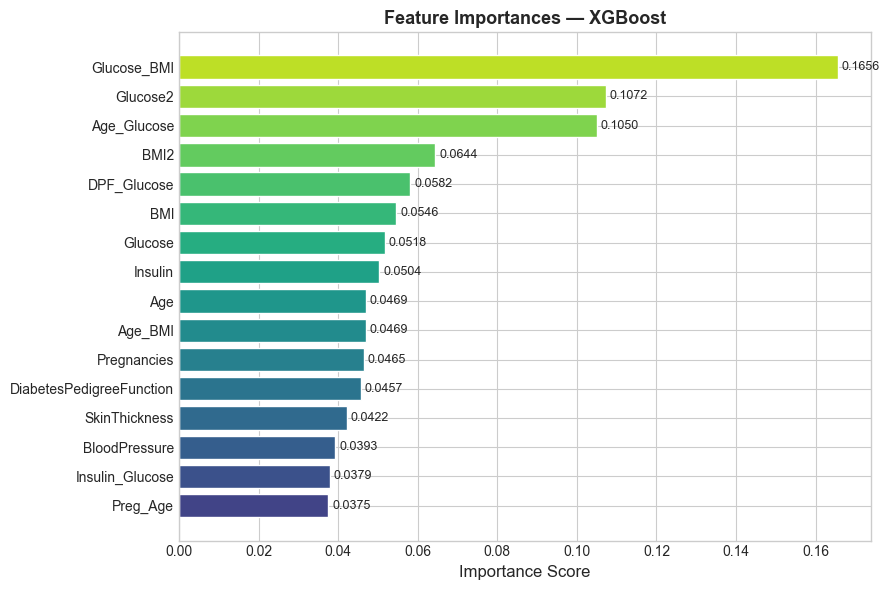

In [40]:
if hasattr(best['model'], 'feature_importances_'):
    imp_df = pd.DataFrame({'Feature': X_fe.columns,
                           'Importance': best['model'].feature_importances_}) \
               .sort_values('Importance', ascending=True)
    fig, ax = plt.subplots(figsize=(9, 6))
    clr = plt.cm.viridis(np.linspace(0.2, 0.9, len(imp_df)))
    bars = ax.barh(imp_df['Feature'], imp_df['Importance'], color=clr, edgecolor='white')
    for bar, val in zip(bars, imp_df['Importance']):
        ax.text(bar.get_width()+0.001, bar.get_y()+bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=9)
    ax.set_xlabel('Importance Score', fontsize=12)
    ax.set_title(f'Feature Importances — {best_name}', fontweight='bold', fontsize=13)
    plt.tight_layout(); plt.show()

---
## 8. Save Artifacts for Streamlit

> Three files are saved here and loaded directly by the Streamlit app:  
> - `diabetes_model.pkl` — the best trained classifier  
> - `diabetes_scaler.pkl` — RobustScaler (fitted on SMOTE-augmented train set with engineered features)  
> - `diabetes_imputer.pkl` — KNNImputer (fitted on raw 8 features)  
>
> The Streamlit app must apply them **in order**: impute → add_features → scale → predict.

In [41]:
# ── Save all three artifacts ─────────────────────────────────────────────
joblib.dump(best['model'],  '../models/diabetes_model.pkl')
joblib.dump(scaler_fe,      '../models/diabetes_scaler.pkl')
joblib.dump(knn_imputer,    '../models/diabetes_imputer.pkl')

print("✅ Saved:")
print("   diabetes_model.pkl   — best classifier")
print("   diabetes_scaler.pkl  — RobustScaler (16 features after engineering)")
print("   diabetes_imputer.pkl — KNNImputer (8 base features)")

# ── Verify round-trip ─────────────────────────────────────────────────────
model_loaded   = joblib.load('../models/diabetes_model.pkl')
scaler_loaded  = joblib.load('../models/diabetes_scaler.pkl')
imputer_loaded = joblib.load('../models/diabetes_imputer.pkl')

acc_verify = accuracy_score(y_test_fe, model_loaded.predict(X_te_sc))
print(f"\n✅ Verification — loaded model test accuracy: {acc_verify:.4f}")

✅ Saved:
   diabetes_model.pkl   — best classifier
   diabetes_scaler.pkl  — RobustScaler (16 features after engineering)
   diabetes_imputer.pkl — KNNImputer (8 base features)

✅ Verification — loaded model test accuracy: 0.7338


In [42]:
# ── Prediction function (mirrors Streamlit app logic) ─────────────────────
BASE_COLS = ['Pregnancies','Glucose','BloodPressure','SkinThickness',
             'Insulin','BMI','DiabetesPedigreeFunction','Age']

def predict_diabetes(patient: dict) -> dict:
    """
    End-to-end prediction for a single patient.
    This function is copy-pasted into the Streamlit app.
    """
    df_p = pd.DataFrame([patient], columns=BASE_COLS)
    # 1. Zero → NaN
    for col in ZERO_INVALID:
        df_p[col] = df_p[col].replace(0, np.nan)
    # 2. KNN impute
    df_imp = pd.DataFrame(imputer_loaded.transform(df_p), columns=BASE_COLS)
    # 3. Feature engineering (must match training exactly)
    df_fe  = add_features(df_imp)
    # 4. Scale
    df_sc  = scaler_loaded.transform(df_fe)
    # 5. Predict
    pred   = model_loaded.predict(df_sc)[0]
    prob   = model_loaded.predict_proba(df_sc)[0][1]
    risk   = 'HIGH' if prob >= 0.6 else ('MODERATE' if prob >= 0.35 else 'LOW')
    return {'Prediction': 'Diabetic' if pred==1 else 'Non-Diabetic',
            'Probability': f'{prob*100:.1f}%',
            'Risk Level': risk, 'Model': best_name}

# Test on two known rows
for label, pt in [
    ('Row 0 — expected Diabetic',
     dict(Pregnancies=6,Glucose=148,BloodPressure=72,SkinThickness=35,
          Insulin=0,BMI=33.6,DiabetesPedigreeFunction=0.627,Age=50)),
    ('Row 1 — expected Non-Diabetic',
     dict(Pregnancies=1,Glucose=85,BloodPressure=66,SkinThickness=29,
          Insulin=0,BMI=26.6,DiabetesPedigreeFunction=0.351,Age=31)),
]:
    r = predict_diabetes(pt)
    print(f"\n{label}")
    for k, v in r.items(): print(f"   {k:<14}: {v}")


Row 0 — expected Diabetic
   Prediction    : Diabetic
   Probability   : 97.3%
   Risk Level    : HIGH
   Model         : XGBoost

Row 1 — expected Non-Diabetic
   Prediction    : Non-Diabetic
   Probability   : 0.1%
   Risk Level    : LOW
   Model         : XGBoost


---
## Summary

| Stage | Technique | Key Decision |
|-------|-----------|-------------|
| Missing data | KNNImputer (k=5, distance-weighted) | Zeros in Glucose/BMI/BP are physiologically impossible |
| Outliers | IQR × 1.5 capping | Clips extremes without deleting rows |
| Class imbalance | Manual SMOTE — train only | No data leakage; fixes 65/35 split |
| Scaling | RobustScaler | Median + IQR — robust to remaining outliers |
| Feature engineering | 8 interaction terms (Glucose², BMI², Age×Glucose, etc.) | Captures non-linear diabetes risk signals |
| Model selection | 10 classifiers + 10-fold CV | Covers linear, kernel, tree, boosting, ensemble |
| Tuning | RandomizedSearchCV (50 iter, 5-fold) | Efficient search over large hyperparameter space |
| Ensemble | Soft Voting Classifier | Averages probability outputs for robust prediction |
| Export | `joblib.dump` × 3 | Model + scaler + imputer → loaded directly by Streamlit |